# **LightGBM**

## **1. Import Libraires**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score
)

import lightgbm as lgb

SEED = 42
np.random.seed(SEED)

## **2. Load Dataset**

In [ ]:
df = pd.read_csv("dataset\\digital_marketing_campaign_dataset.csv")   
df = df.drop(columns=["CustomerID", "AdvertisingPlatform", "AdvertisingTool"])
df.head()

## **3. Data Preprocessing**

In [ ]:
# Selected features from inferential analysis (excluding ConversionRate - data leakage risk)
FEATURES = [
    "CampaignType", 
    "AdSpend", 
    "ClickThroughRate", 
    "WebsiteVisits",
    "PagesPerVisit", 
    "TimeOnSite", 
    "EmailOpens", 
    "EmailClicks",
    "PreviousPurchases", 
    "LoyaltyPoints"
]
TARGET = "Conversion"

# Encode categorical
le = LabelEncoder()
df["CampaignType"] = le.fit_transform(df["CampaignType"])

X = df[FEATURES]
y = df[TARGET]

# Split data
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
print(f"scale_pos_weight = {pos_weight:.4f}\n")

## **4. Model Architecture — LightGBM**

In [ ]:

params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'num_leaves': 96,
    'max_depth': 7,
    'learning_rate': 0.025,
    'feature_fraction': 0.82,
    'bagging_fraction': 0.85,
    'bagging_freq': 5,
    'min_child_samples': 35,
    'scale_pos_weight': pos_weight,
    'lambda_l1': 1.5,
    'lambda_l2': 2.0,
    'verbose': -1,
    'seed': SEED,
    'num_threads': -1
}

train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

## **5. Training**

In [ ]:
evals_result = {}

model = lgb.train(
    params,
    train_data,
    num_boost_round=3000,
    valid_sets=[train_data, val_data],
    valid_names=['train', 'valid'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=150, verbose=True),
        lgb.log_evaluation(100),
        lgb.record_evaluation(evals_result)
    ]
)


## **6. Evaluation on Test Set**

In [54]:
y_prob = model.predict(X_test)

y_pred = (y_prob >= 0.5).astype(int)

acc     = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

summary = pd.DataFrame({
    "Metric" : ["Accuracy", "ROC-AUC"],
    "Score"  : [round(acc, 4), round(roc_auc, 4)]
})
summary


,Metric,Score
0,Accuracy,0.8608
1,ROC-AUC,0.7918


### **6.1 Classification Report**

In [44]:
report = classification_report(y_test, y_pred, target_names=["Not Converted (0)", "Converted (1)"],
                                output_dict=True)
pd.DataFrame(report).T.round(4)

,precision,recall,f1-score,support
Not Converted (0),0.5674,0.5405,0.5536,148.0000
Converted (1),0.9358,0.9420,0.9389,1052.0000
accuracy,0.8925,0.8925,0.8925,0.8925
macro avg,0.7516,0.7413,0.7463,1200.0000
weighted avg,0.8904,0.8925,0.8914,1200.0000


### **6.2 Confusion Matrix**

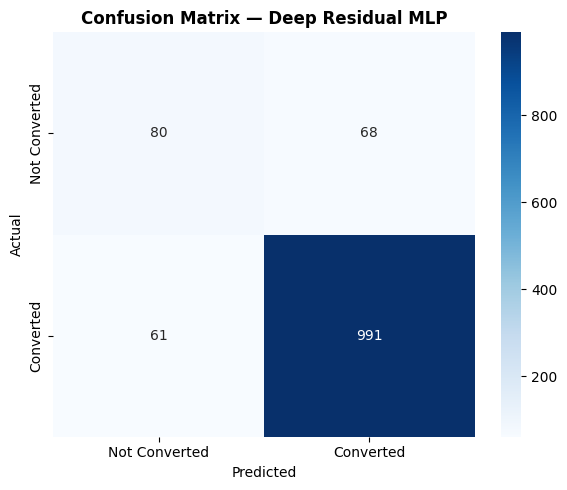

In [45]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Not Converted", "Converted"],
    yticklabels=["Not Converted", "Converted"]
)
plt.title("Confusion Matrix — Deep Residual MLP", fontweight="bold")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

### **6.3 ROC Curve**

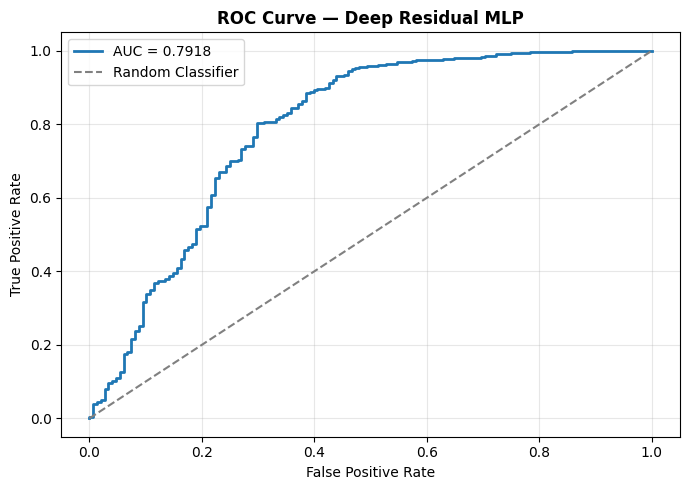

In [46]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random Classifier")
plt.title("ROC Curve — Deep Residual MLP", fontweight="bold")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## **6.4 Feature Importance (Gain)**

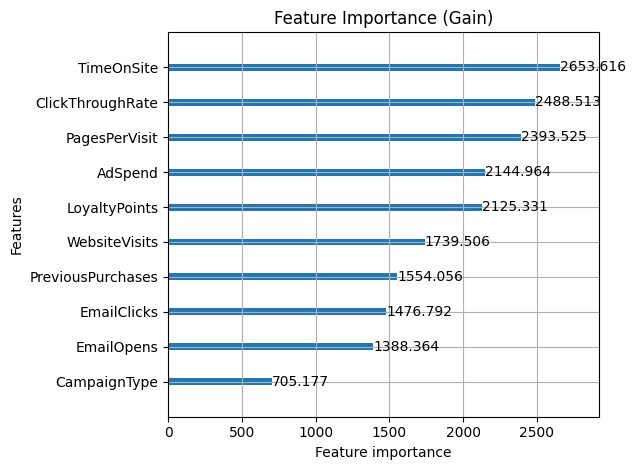

In [51]:
lgb.plot_importance(model, max_num_features=10, importance_type='gain', ax=plt.gca())
plt.title('Feature Importance (Gain)')
plt.tight_layout()
plt.show()